# Obtaining the Graphs for ASTROMoRF Journal Paper.

This script obtains the graphs for the pickle files run on an HPC


## Load Necessary Modules

In [1]:
import sys
import pathlib
from pathlib import Path
import os
import logging
import types


import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

from simopt.experiment_base import (
    ProblemsSolvers,
    read_experiment_results,
    PlotType, 
    plot_solvability_profiles, 
    plot_budget_history, 
    plot_fn_estimates, 
    plot_progress_curves
)
from demo.plot_datafarming import plot_datafarming_results, create_results_dataframe

#Get the experiments Results directory where all the ProblemsSolvers pickles will be stored
experiment_dir = Path.cwd() / "experiments" / "Journal_Test_Results"
if not experiment_dir.exists():
    os.makedirs(experiment_dir)




sys.modules["pathlib._local"] = types.ModuleType("pathlib._local")
sys.modules["pathlib._local"].PosixPath = pathlib.PosixPath
sys.modules["pathlib._local"].WindowsPath = pathlib.WindowsPath

### EXPERIMENT 1: Comparison of Solvers

In this experiment we compare ASTROMoRF against other state of the art solvers on a testbed of SO problems. We get plots for the solvability profiles as well as change in function estimates and budget over the run for each solver.


In [ ]:


path_comparison = "/Users/benjaminrees/Desktop/Journal_Pickles/comparison_experiments/"

#find all the pickles in the directory that contain "POSTREPS" in the filename - get a list of their file paths
pickles = [f for f in os.listdir(path_comparison) if f.endswith('.pickle') and "POSTREPS" in f]

print(f"Found {len(pickles)} pickles")
[print(f) for f in pickles]

#now load. the pickle files as ProblemsSolvers objects

ps_list = []
experiments_comparison = []
for pkl in pickles:
    #load in experiments but if the solver is RNDSR, skip it
    experiment = read_experiment_results(os.path.join(path_comparison, pkl))
    if experiment.solver.name == "RANDOM SEARCH":
        print(f"Skipping RNDSR experiment: {pkl}")
        continue
    experiments_comparison.append(experiment) 

print(f"Loaded {len(experiments_comparison)} experiments after filtering out RNDSR")

#print the number of macroreps for each experiment
for exp in experiments_comparison:
    print(f"Experiment: {exp.solver.name} on {exp.problem.name} has {exp.n_macroreps} macroreps")

    


In [ ]:
#Create an instance of ProblemsSolvers that contains all the experiments

#first need to make experiments a list of list of ProblemSolver objects where each inner list has the same solver 

experiments_sorted = {}
for exp in experiments_comparison:
    key = exp.solver.name
    if key not in experiments_sorted:
        experiments_sorted[key] = []
    experiments_sorted[key].append(exp)

# pretty print each solver and problem pair in the experiments_sorted
for solver_name, exps in experiments_sorted.items():
    for exp in exps:
        print(f"Solver: {solver_name}, Problem: {exp.problem.name}")
    print("\n")

#now turn experiments_sorted into a list of lists where each value of the dict is a sublist 
ps_list = list(experiments_sorted.values())

file_name_path = experiment_dir / "comparison_experiment_results.pickle"
comparison_experiment = ProblemsSolvers(experiments=ps_list, file_name_path=file_name_path)

print(f'Comparison ProblemsSolvers has file path: {comparison_experiment.file_name_path}')


In [ ]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = experiments_comparison[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
comparison_experiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

In [ ]:
# Produce basic plots.
import matplotlib.pyplot as plt
from IPython.display import Image, display

from simopt.experiment_base import PlotType, plot_solvability_profiles, plot_budget_history, plot_fn_estimates, plot_progress_curves


print("Plotting results...")

ps_same_problem_dict = {}
# take the experiments of comparison_experiment and create a list of lists from ps_same_problem_list where each sublist contains all solvers for a given problem
experiments_flattened = [ps for solver_experiments in comparison_experiment.experiments for ps in solver_experiments]
for exp in experiments_flattened:
    if exp.problem.name not in ps_same_problem_dict:
        ps_same_problem_dict[exp.problem.name] = []
    ps_same_problem_dict[exp.problem.name].append(exp)

#turn the items of ps_same_problem_dict into a list of lists
experiments_flattened = []
for problem_name, ps_list in ps_same_problem_dict.items():
    experiments_flattened.append(ps_list)


def _print_path_and_display(plot_paths: list[Path]) -> None:
    for plot_path in plot_paths:
        print(f"Plot saved to {plot_path!s}")
        display(Image(filename=str(plot_path)))


_print_path_and_display(
    plot_solvability_profiles(
        experiments=comparison_experiment.experiments, 
        plot_type=PlotType.CDF_SOLVABILITY,
        legend_loc="upper right",
        plot_title="Performance of State-of-the-Art Solvers against ASTROMoRF"
    )
)


for problem in experiments_flattened:
    _print_path_and_display(
        plot_progress_curves(
            experiments=problem, 
            plot_type=PlotType.MEAN, 
            solver_set_name="ASTRO-DF and ASTROMoRF", 
            normalize=True,
            allow_xstar_mismatch=True
        )
    )

# comparison_experiment.experiments is structured as experiments[solver_idx][problem_idx]
# To plot all solvers for each problem, we need to transpose the structure
n_solvers = len(comparison_experiment.experiments)
n_problems = len(comparison_experiment.experiments[0]) if n_solvers > 0 else 0

for prob_idx in range(n_problems):
    # Collect all solvers for this problem
    solvers_for_problem = [comparison_experiment.experiments[solver_idx][prob_idx] for solver_idx in range(n_solvers)]


    # Maybe move the y-axis to being logarithmic 
    _print_path_and_display(
        plot_fn_estimates(
            experiments=solvers_for_problem,
            plot_type=PlotType.FN_ESTIMATES_MEAN, 
            solver_set_name="ASTRO-DF and ASTROMoRF", 
            normalize=True,
            y_normalize=True,
            all_in_one=True
        )
    )
    _print_path_and_display(
        plot_budget_history(
            experiments=solvers_for_problem,
            plot_type=PlotType.BUDGET_HISTORY_MEAN, 
            solver_set_name="ASTRO-DF and ASTROMoRF", 
            normalize=True
        )
    )

print("Plotting complete!")

### EXPERIMENT 2: Comparing the performance of ASTROMoRF ON CRN vs NON-CRN

In this experiment we compare the performance of ASTROMoRF under CRN on each problem vs Non-CRN

In [ ]:
#load in the 
path_crn = "/Users/benjaminrees/Desktop/Journal_Pickles/crn_experiments/"
pickles_crn = [f for f in os.listdir(path_crn) if f.endswith('.pickle') and "POSTREPS" in f]

#from the experiments_comparison, get the experiments with the solver.name "ASTROMoRF"
astromorf_experiments = []
for exp in experiments_comparison:
    if exp.solver.name == "ASTROMoRF":
        #rename exp to be ASTROMoRF_CRN_False
        exp.solver.name = "ASTROMoRF_CRN_False"
        astromorf_experiments.append(exp)   

#now load in the CRN experiments and append to the astromorf_experiments list
for pkl in pickles_crn:
    experiment = read_experiment_results(os.path.join(path_crn, pkl))
    astromorf_experiments.append(experiment) 

In [ ]:
#Create an instance of ProblemsSolvers that contains all the experiments

#first need to make experiments a list of list of ProblemSolver objects where each inner list has the same solver 

experiments_sorted_crn = {}
for exp in astromorf_experiments:
    key = exp.solver.name
    if key not in experiments_sorted_crn:
        experiments_sorted_crn[key] = []
    experiments_sorted_crn[key].append(exp)

# pretty print each solver and problem pair in the experiments_sorted
for solver_name, exps in experiments_sorted_crn.items():
    for exp in exps:
        print(f"Solver: {solver_name}, Problem: {exp.problem.name}")
    print("\n")

#now turn experiments_sorted into a list of lists where each value of the dict is a sublist 
ps_list_crn = list(experiments_sorted_crn.values())
crn_experiment = ProblemsSolvers(experiments=ps_list_crn, file_name_path="crn_experiment_results")

In [ ]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = astromorf_experiments[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
crn_experiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

In [ ]:


print("Plotting results...")

ps_same_problem_dict = {}
# take the experiments of comparison_experiment and create a list of lists from ps_same_problem_list where each sublist contains all solvers for a given problem
experiments_flattened = [ps for solver_experiments in comparison_experiment.experiments for ps in solver_experiments]
for exp in experiments_flattened:
    if exp.problem.name not in ps_same_problem_dict:
        ps_same_problem_dict[exp.problem.name] = []
    ps_same_problem_dict[exp.problem.name].append(exp)

#turn the items of ps_same_problem_dict into a list of lists
experiments_flattened = []
for problem_name, ps_list in ps_same_problem_dict.items():
    experiments_flattened.append(ps_list)








def _print_path_and_display(plot_paths: list[Path]) -> None:
    for plot_path in plot_paths:
        print(f"Plot saved to {plot_path!s}")
        display(Image(filename=str(plot_path)))


_print_path_and_display(
    plot_solvability_profiles(
        experiments=comparison_experiment.experiments, plot_type=PlotType.CDF_SOLVABILITY
    )
)


for problem in experiments_flattened:
    _print_path_and_display(
        plot_progress_curves(
            experiments=problem, 
            plot_type=PlotType.MEAN, 
            solver_set_name="ASTRO-DF and ASTROMoRF", 
            normalize=True,
            allow_xstar_mismatch=True
        )
    )

# comparison_experiment.experiments is structured as experiments[solver_idx][problem_idx]
# To plot all solvers for each problem, we need to transpose the structure
n_solvers = len(comparison_experiment.experiments)
n_problems = len(comparison_experiment.experiments[0]) if n_solvers > 0 else 0

for prob_idx in range(n_problems):
    # Collect all solvers for this problem
    solvers_for_problem = [comparison_experiment.experiments[solver_idx][prob_idx] for solver_idx in range(n_solvers)]

    #get the terminal budget for each problem solver 
    [print(f"solver {s.solver.name} on problem {s.problem.name} has budget {[x[-1] for x in s.all_budget_history]}") for s in solvers_for_problem]


    # Maybe move the y-axis to being logarithmic 
    _print_path_and_display(
        plot_fn_estimates(
            experiments=solvers_for_problem,
            plot_type=PlotType.FN_ESTIMATES_MEAN, 
            solver_set_name="ASTRO-DF and ASTROMoRF", 
            normalize=True,
            all_in_one=False
        )
    )
    _print_path_and_display(
        plot_budget_history(
            experiments=solvers_for_problem,
            plot_type=PlotType.BUDGET_HISTORY_MEAN, 
            solver_set_name="ASTRO-DF and ASTROMoRF", 
            normalize=True
        )
    )

print("Plotting complete!")

## EXPERIMENT 3: Datafarming on Polynomial Basis Type and Subspace Dimension

This final experiment looks at how the polynomial basis type and initial subspace dimension affects the performance of ASTROMoRF

In [2]:
#load in the subspace datafarming experiments
path_datafarming_subspace = "/Users/benjaminrees/Desktop/Journal_Pickles/datafarming_experiments/Subspace"
pickles_datafarming_subspace = [f for f in os.listdir(path_datafarming_subspace) if f.endswith('.pickle') and "POSTREPS" in f]

#from the experiments_comparison, get the experiments with the solver.name "ASTROMoRF"
datafarming_experiments_subspace = []
#now load in the CRN experiments and append to the astromorf_experiments list
for pkl in pickles_datafarming_subspace:
    #only test on SAN-1 problems
    experiment = read_experiment_results(os.path.join(path_datafarming_subspace, pkl))
    datafarming_experiments_subspace.append(experiment) 

In [3]:
#load in the polybases datafarming experiments
path_datafarming_polybases = "/Users/benjaminrees/Desktop/Journal_Pickles/datafarming_experiments/PolynomialBases"
pickles_datafarming_polybases = [f for f in os.listdir(path_datafarming_polybases) if f.endswith('.pickle') and "POSTREPS" in f]

#from the experiments_comparison, get the experiments with the solver.name "ASTROMoRF"
datafarming_experiments_polybases = []
#now load in the CRN experiments and append to the astromorf_experiments list
for pkl in pickles_datafarming_polybases:
    experiment = read_experiment_results(os.path.join(path_datafarming_polybases, pkl))
    datafarming_experiments_polybases.append(experiment) 

In [4]:
experiments_sorted_datafarming_subspace = {}
for exp in datafarming_experiments_subspace:
    key = exp.solver.name
    if key not in experiments_sorted_datafarming_subspace:
        experiments_sorted_datafarming_subspace[key] = []
    experiments_sorted_datafarming_subspace[key].append(exp)

#now turn experiments_sorted into a list of lists where each value of the dict is a sublist 
ps_list_datafarming_subspace = list(experiments_sorted_datafarming_subspace.values())
file_name_path_subspace = experiment_dir / "datafarming_experiment_results_subspace.pickle"
datafarming_experiment_subspace = ProblemsSolvers(experiments=ps_list_datafarming_subspace, file_name_path=file_name_path_subspace)

In [5]:
experiments_sorted_datafarming_polybases = {}
for exp in datafarming_experiments_polybases:
    key = exp.solver.name
    if key not in experiments_sorted_datafarming_polybases:
        experiments_sorted_datafarming_polybases[key] = []
    experiments_sorted_datafarming_polybases[key].append(exp)

#now turn experiments_sorted into a list of lists where each value of the dict is a sublist 
ps_list_datafarming_polybases = list(experiments_sorted_datafarming_polybases.values())
file_name_path_polybases = experiment_dir / "datafarming_experiment_results_polybases.pickle"
datafarming_experiment_polybases = ProblemsSolvers(experiments=ps_list_datafarming_polybases, file_name_path=file_name_path_polybases)

In [6]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = datafarming_experiments_subspace[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

datafarming_experiment_subspace.post_normalize(
    n_postreps_init_opt=num_postreps_init_opt,
)
# Record and log results
datafarming_experiment_subspace.record_group_experiment_results()
datafarming_experiment_subspace.log_group_experiment_results()
datafarming_experiment_subspace.report_group_statistics()

2026-01-19 20:01:07,282 | INFO | Postnormalizing on Problem NETWORK-1.
2026-01-19 20:01:07,472 | INFO | Global proxy x* computed for problem NETWORK-1.
2026-01-19 20:01:07,473 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.


Logging set to INFO. You will see per-pair progress as they start/finish.
Post-normalizing results.


2026-01-19 20:01:07,659 | INFO | Postnormalizing on Problem SAN-1.
2026-01-19 20:01:07,670 | INFO | Global proxy x* computed for problem SAN-1.
2026-01-19 20:01:07,671 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-19 20:01:07,682 | INFO | Postnormalizing on Problem ROSENBROCK-1.
2026-01-19 20:01:07,683 | INFO | Finding f(x*) using coded f(x*).
2026-01-19 20:01:07,691 | INFO | Postnormalizing on Problem NETWORK-1.
2026-01-19 20:01:07,874 | INFO | Global proxy x* computed for problem NETWORK-1.
2026-01-19 20:01:07,875 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-19 20:01:08,056 | INFO | Postnormalizing on Problem ROSENBROCK-1.
2026-01-19 20:01:08,057 | INFO | Finding f(x*) using coded f(x*).
2026-01-19 20:01:08,066 | INFO | Postnormalizing on Problem DYNAMNEWS-1.
2026-01-19 20:01:08,210 | INFO | Global proxy x* computed for problem DYNAMNEWS-1.
2026-01-19 20:01:08,211 | INFO | Finding f(x

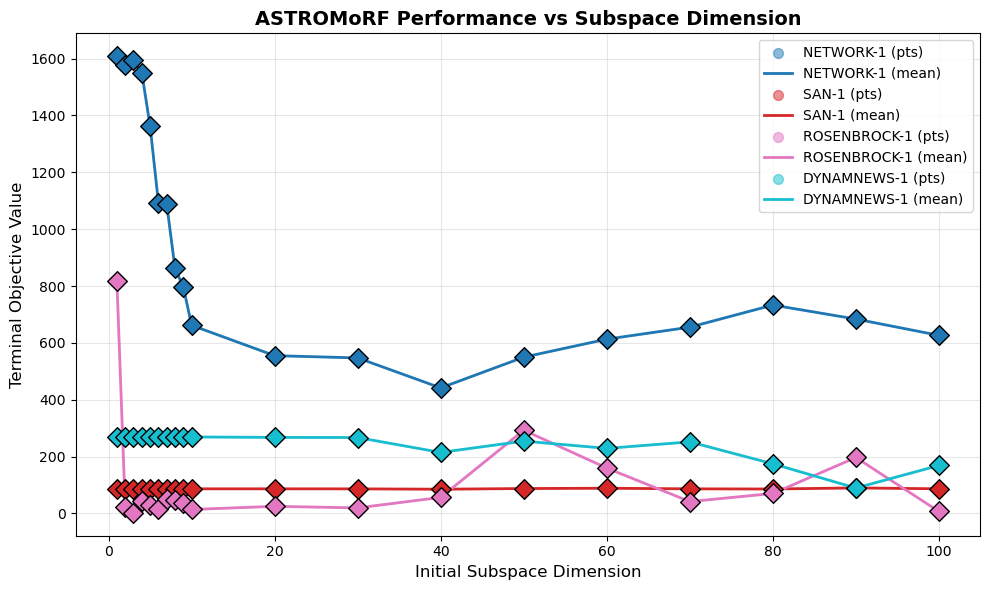

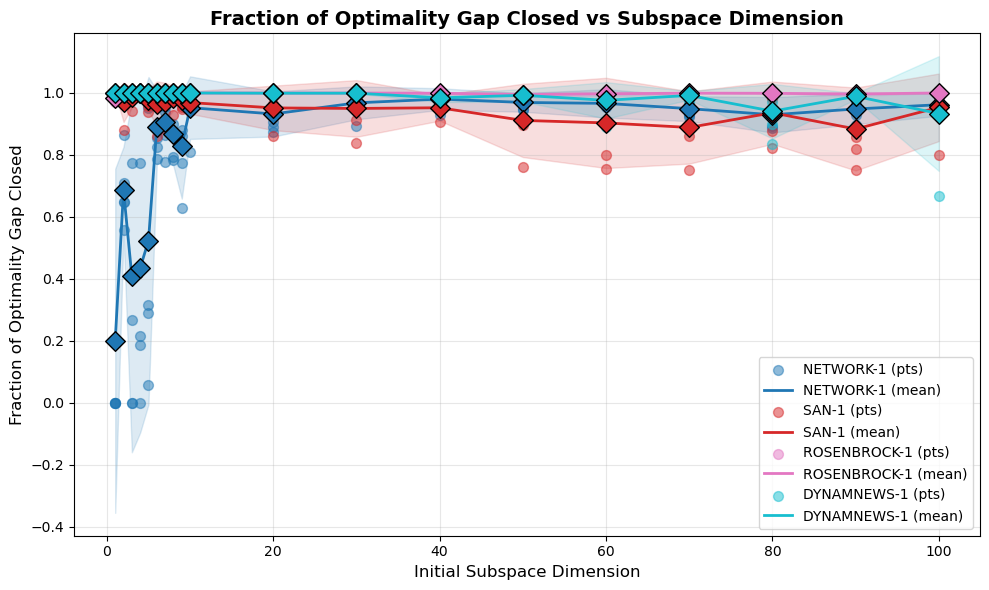

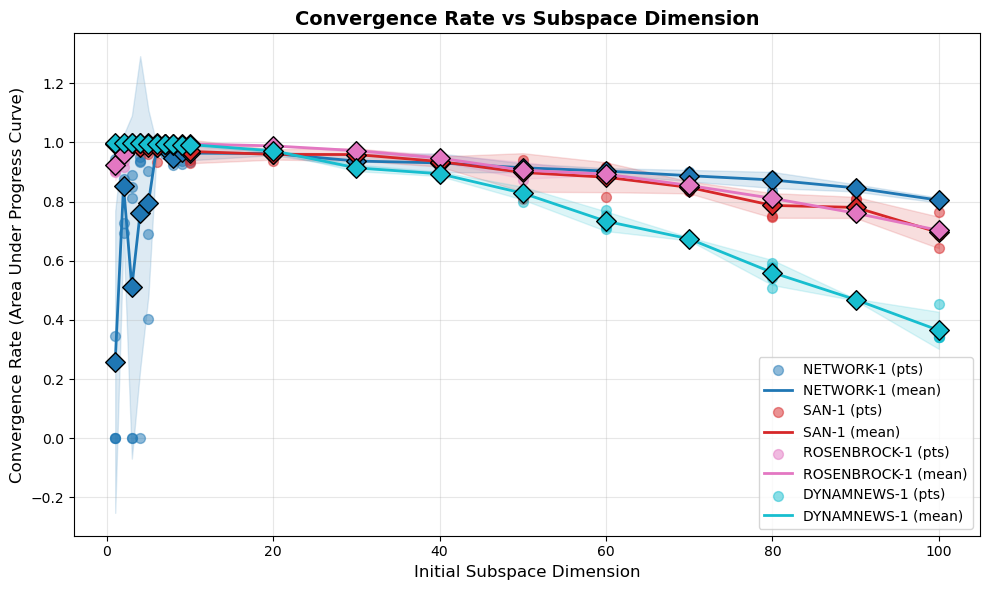

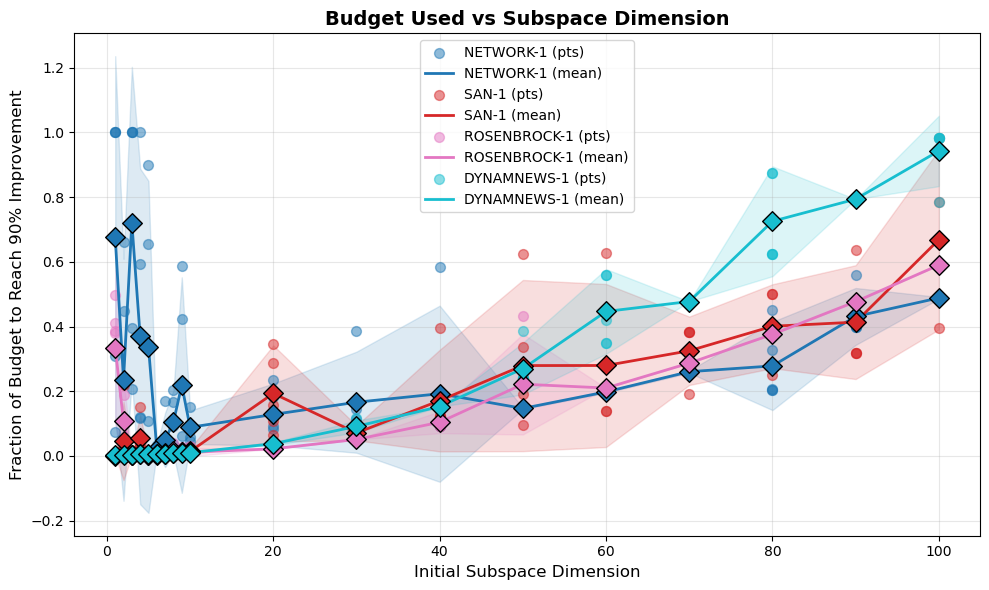

In [7]:
# Plot the data farming results

#Reload the module to get any recent changes
# import importlib
# import demo.plot_datafarming
# importlib.reload(demo.plot_datafarming)

# Plot terminal objective vs subspace dimension
fig, ax = plot_datafarming_results(
    experiments=datafarming_experiment_subspace,  # Pass the ProblemsSolvers object directly
    factor_name="initial subspace dimension",
    y_metric="terminal_objective",
    title="ASTROMoRF Performance vs Subspace Dimension",
    show_confidence_interval=True,
)

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_subspace,
    factor_name="initial subspace dimension", 
    y_metric="fraction_closed",
    title="Fraction of Optimality Gap Closed vs Subspace Dimension",
)

# Alternatively, plot the fraction of optimality gap closed
# fig2, ax2 = plot_datafarming_results(
#     experiments=datafarming_experiment_subspace,
#     factor_name="initial subspace dimension", 
#     y_metric="optimality_gap_fraction",
#     title="Fraction of Optimality Gap Closed vs Subspace Dimension",
# )

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_subspace,
    factor_name="initial subspace dimension", 
    y_metric="convergence_rate",
    convergence_method="area_ratio",
    title="Convergence Rate vs Subspace Dimension",
)


# fig3, ax3 = plot_datafarming_results(
#     experiments=datafarming_experiment_subspace,
#     factor_name="initial subspace dimension", 
#     y_metric="convergence_rate",
#     convergence_method="linear_fit",
#     title="Convergence Rate vs Subspace Dimension",
# )

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_subspace,
    factor_name="initial subspace dimension", 
    y_metric="convergence_rate",
    convergence_method="budget_to_threshold",
    title="Budget Used vs Subspace Dimension",
)

In [8]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = datafarming_experiments_polybases[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

datafarming_experiment_polybases.post_normalize(
    n_postreps_init_opt=num_postreps_init_opt,
)
# Record and log results
datafarming_experiment_polybases.record_group_experiment_results()
datafarming_experiment_polybases.log_group_experiment_results()
datafarming_experiment_polybases.report_group_statistics()

2026-01-19 20:01:29,829 | INFO | Postnormalizing on Problem NETWORK-1.


Logging set to INFO. You will see per-pair progress as they start/finish.
Post-normalizing results.


2026-01-19 20:01:30,043 | INFO | Global proxy x* computed for problem NETWORK-1.
2026-01-19 20:01:30,043 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-19 20:01:30,227 | INFO | Postnormalizing on Problem DYNAMNEWS-1.
2026-01-19 20:01:30,372 | INFO | Global proxy x* computed for problem DYNAMNEWS-1.
2026-01-19 20:01:30,373 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-19 20:01:30,519 | INFO | Postnormalizing on Problem NETWORK-1.
2026-01-19 20:01:30,704 | INFO | Global proxy x* computed for problem NETWORK-1.
2026-01-19 20:01:30,704 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-19 20:01:30,891 | INFO | Postnormalizing on Problem DYNAMNEWS-1.
2026-01-19 20:01:31,040 | INFO | Global proxy x* computed for problem DYNAMNEWS-1.
2026-01-19 20:01:31,041 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01

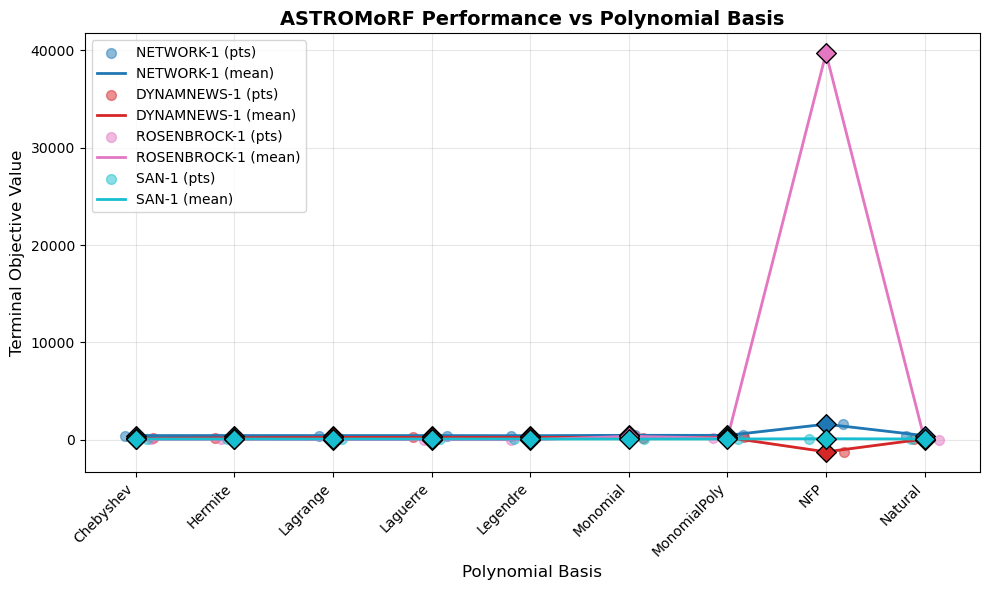

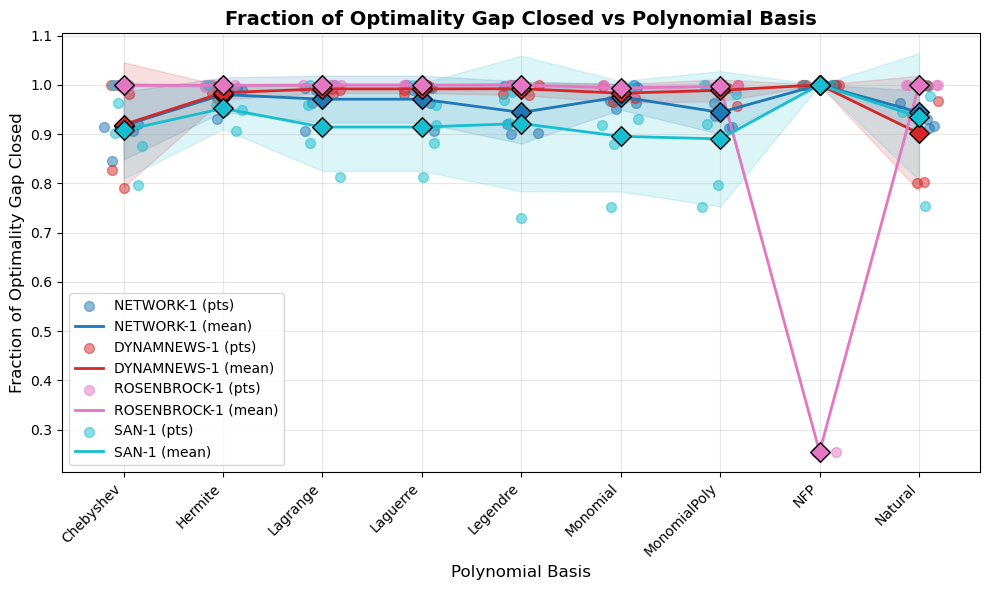

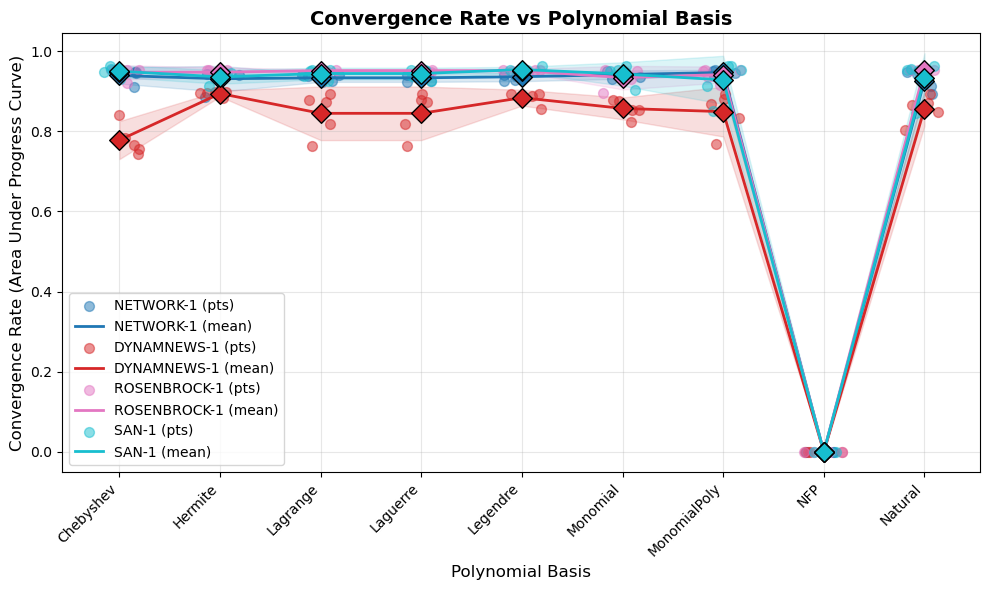

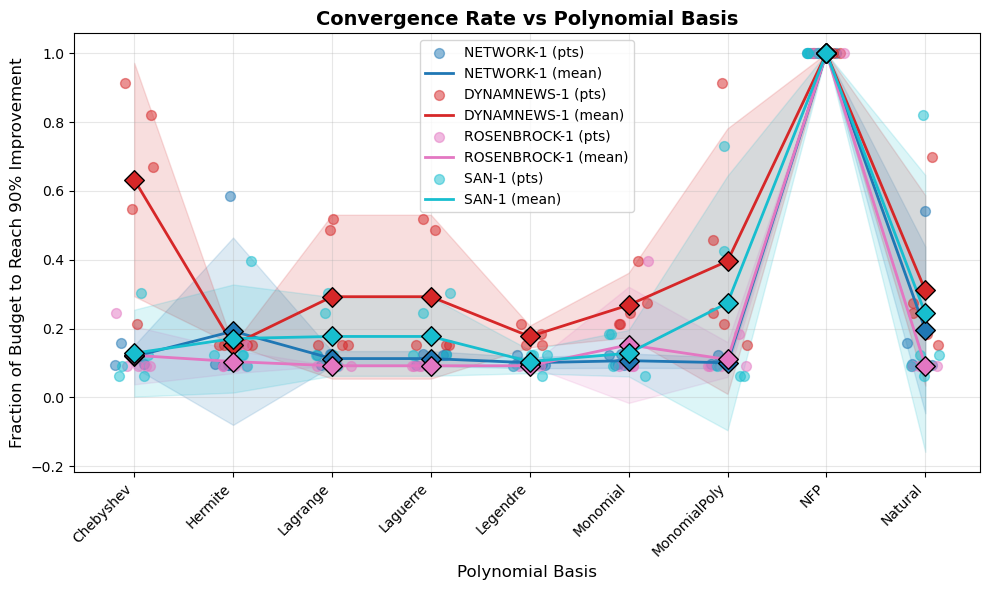

In [10]:
fig, ax = plot_datafarming_results(
    experiments=datafarming_experiment_polybases,  # Pass the ProblemsSolvers object directly
    factor_name="polynomial basis",
    y_metric="terminal_objective",
    title="ASTROMoRF Performance vs Polynomial Basis",
    show_confidence_interval=True,
)

# Alternatively, plot the fraction of optimality gap closed
fig2, ax2 = plot_datafarming_results(
    experiments=datafarming_experiment_polybases,
    factor_name="polynomial basis", 
    y_metric="fraction_closed",
    title="Fraction of Optimality Gap Closed vs Polynomial Basis",
)

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_polybases,
    factor_name="polynomial basis", 
    y_metric="convergence_rate",
    convergence_method="area_ratio",
    title="Convergence Rate vs Polynomial Basis",
)

# fig3, ax3 = plot_datafarming_results(
#     experiments=datafarming_experiment_polybases,
#     factor_name="polynomial basis", 
#     y_metric="convergence_rate",
#     convergence_method="linear_fit",
#     title="Convergence Rate vs Polynomial Basis",
# )

fig3, ax3 = plot_datafarming_results(
    experiments=datafarming_experiment_polybases,
    factor_name="polynomial basis", 
    y_metric="convergence_rate",
    convergence_method="budget_to_threshold",
    title="Convergence Rate vs Polynomial Basis",
)

In [ ]:
# # Create a DataFrame for further analysis
# df = create_results_dataframe(
#     experiments=datafarming_experiment,
#     factor_names=["initial subspace dimension", "polynomial basis"],
# )


# print(df.head(10))